In [2]:
pip install tensorflow


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 2.9 MB/s eta 0:02:03
   ---------------------------------------- 1.6/351.2 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 2.1/351.2 MB 2.9 MB/s eta 0:02:00
   ---------------------------------------- 2.9/351.2 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 3.4/351.2 MB 3.0 MB/s eta 0:01:56
   ---------------------------------------- 4.2/351.2 MB 3.0 MB/s eta 0:01:54
    --------------------------------------- 4.7/351.2 MB 3.0 MB/s eta 0:01:57
    --------------------------------------- 5.2/351.2 MB 2.9 MB/s eta 0:02:02
    --------------------------------------- 5.5/351.2 MB 2.8 MB/s eta 0:02:05
    --------------------------------------- 6.0/351.2 MB 2.6 MB/s eta 0:02:11
    --------------------------------------- 6.3/351.2 MB 2.6 MB/s eta 0:02:13


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [39]:
Training_Directory=r"C:\DATASET_CNN\TRAINING"
Validation_Directory=r"C:\DATASET_CNN\VALIDATION"

Testing_Directory=r"C:\DATASET_CNN\Testing"

In [40]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

NUM_CLASSES = 10

In [41]:
train_ds = image_dataset_from_directory(
   Training_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = image_dataset_from_directory(
   Validation_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
   Testing_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12723 files belonging to 10 classes.
Found 2724 files belonging to 10 classes.
Found 2730 files belonging to 10 classes.


In [42]:
class_names = train_ds.class_names

print("Classes:\n")

for i, name in enumerate(class_names):
    print(i, "->", name)

Classes:

0 -> Tomato___Bacterial_spot
1 -> Tomato___Early_blight
2 -> Tomato___Late_blight
3 -> Tomato___Leaf_Mold
4 -> Tomato___Septoria_leaf_spot
5 -> Tomato___Spider_mites Two-spotted_spider_mite
6 -> Tomato___Target_Spot
7 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 -> Tomato___Tomato_mosaic_virus
9 -> Tomato___healthy


In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

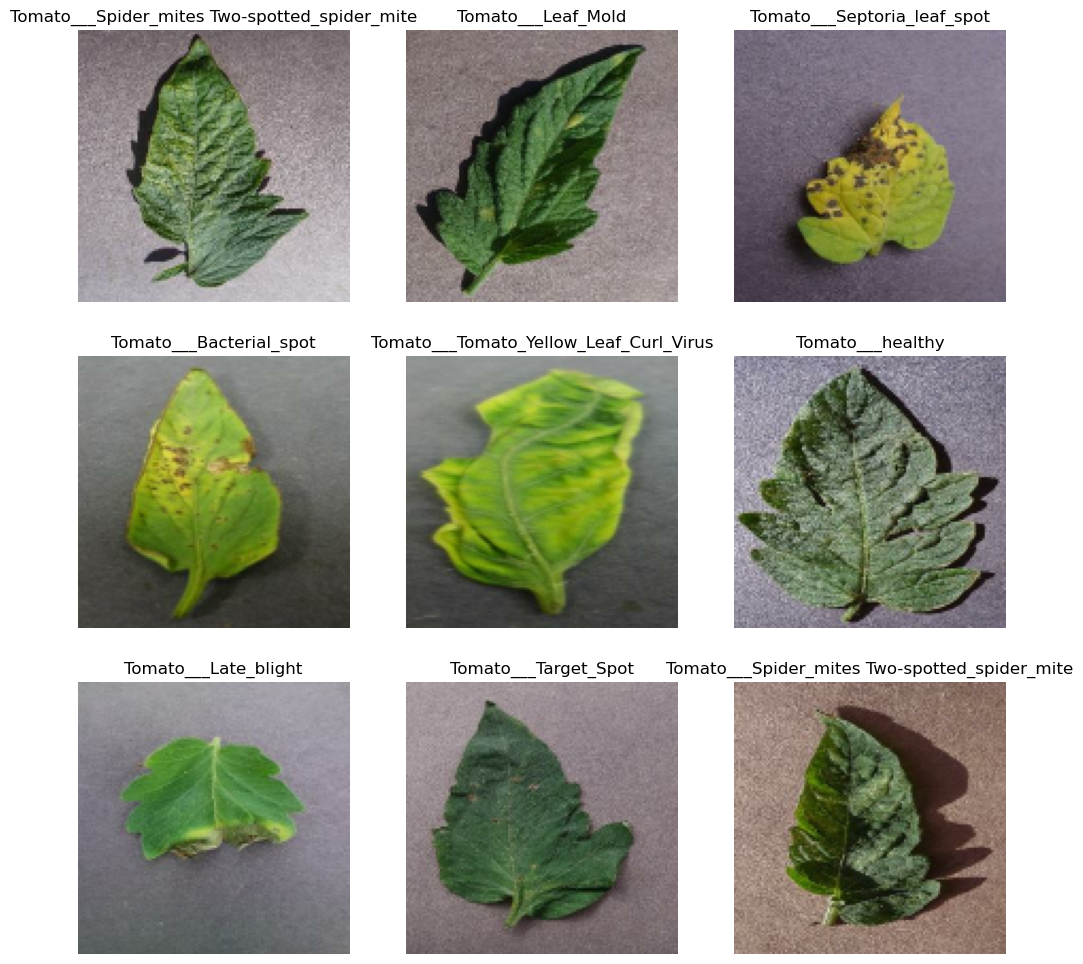

In [44]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [45]:
normalization_layer = layers.Rescaling(1./255)

In [46]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [47]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

 

    normalization_layer,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

   
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
train_ds_raw = image_dataset_from_directory(
    Training_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(train_ds_raw.class_names)

Found 12723 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [18]:
val_ds_raw = image_dataset_from_directory(
    Validation_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(val_ds_raw.class_names)

Found 2724 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [19]:
test_ds_raw = image_dataset_from_directory(
    Testing_Directory,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(test_ds_raw.class_names)


Found 2730 files belonging to 10 classes.
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [50]:
from tensorflow.keras.callbacks import EarlyStopping

EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [51]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 327s 811ms/step - accuracy: 0.7120 - loss: 0.8580 - val_accuracy: 0.2254 - val_loss: 5.5942
Epoch 2/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 313s 787ms/step - accuracy: 0.8288 - loss: 0.5066 - val_accuracy: 0.8697 - val_loss: 0.3943
Epoch 3/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 367s 923ms/step - accuracy: 0.8702 - loss: 0.3830 - val_accuracy: 0.5231 - val_loss: 1.8225
Epoch 4/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 366s 920ms/step - accuracy: 0.9021 - loss: 0.2889 - val_accuracy: 0.7225 - val_loss: 0.9172
Epoch 5/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 334s 839ms/step - accuracy: 0.9193 - loss: 0.2415 - val_accuracy: 0.7232 - val_loss: 1.0562


In [54]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 262ms/step - accuracy: 0.8623 - loss: 0.3997
Test Accuracy: 0.8622710704803467
Test Loss: 0.39970412850379944


In [56]:
model.save("plant_disease_cnn.keras")

In [57]:
    import os

print(os.getcwd())

C:\Users\Lenovo
